# *数智学院课程 — 《数据挖掘》*

## &nbsp;第 §6 和 §7 章：分类模型 I 与 分类模型 II

## &nbsp;课后作业与拓展 <br>

> 教师: 谢海华  
> 学期: 2026 春季  


---

> 作业完成版


#### 1. 概念理解（简答）

**（1）过拟合、方差与偏差**

过拟合是指模型把训练集中的偶然噪声、局部规律也学进去了，导致训练集表现很好，但测试集或新样本表现明显下降。课堂案例中常见现象包括：  
1. 决策树不限制深度时，训练准确率接近 1，但测试准确率下降。  
2. KNN 中 `k=1` 时边界非常曲折，训练误差极低，但泛化能力不稳定。  
3. RBF-SVM 中 `C` 和 `gamma` 很大时，决策边界围绕训练样本剧烈弯曲，对噪声点也强行拟合。

偏差描述模型本身的表达能力是否不足。高偏差模型过于简单，训练集和测试集表现都不好，容易欠拟合。方差描述模型对训练数据扰动是否敏感。高方差模型通常训练表现很好，但测试表现波动大，容易过拟合。好的模型需要在偏差和方差之间平衡：既不能太简单，也不能复杂到记住噪声。

**（2）关于 KNN**

KNN 依赖样本之间的距离。如果不同特征量纲差异很大，例如“收入”取值上万、“房间数”只有个位数，那么距离几乎会被大尺度特征支配，其他特征影响被压低。因此通常需要标准化或归一化。

`k` 太小时，模型只参考极少数邻居，容易受噪声点影响，方差高、偏差低，容易过拟合。`k` 太大时，模型会把很远的样本也纳入判断，局部结构被平均掉，偏差高、方差低，容易欠拟合。

**（3）关于朴素贝叶斯**

条件独立假设是指在类别已知的条件下，各个特征之间相互独立。朴素贝叶斯用这个假设把联合概率分解为多个条件概率的乘积：

\[
P(x_1,x_2,\ldots,x_n|y)=\prod_i P(x_i|y)
\]

现实中文本特征并不严格独立，例如某些词经常一起出现。但朴素贝叶斯在文本分类中仍然常常有效，因为文本的词频维度很高，很多词对类别有强提示作用；即使概率估计不完全准确，最终类别排序仍可能正确。此外，朴素贝叶斯参数少、训练快，在小数据和高维稀疏文本上很稳健。

**（4）关于决策树**

节点纯度指一个节点中的样本是否主要来自同一类别。越纯的节点越容易做出明确分类。建树时希望节点越来越纯，是因为这意味着划分后的子集类别混杂程度降低，预测不确定性下降。

信息增益衡量一次划分带来的熵下降，倾向于选择能最大幅度降低不确定性的特征。但它容易偏好取值很多的特征，例如“ID”类特征可能把每个样本单独分开，看似信息增益很高但没有泛化价值。信息增益率在信息增益基础上除以特征本身的划分复杂度，能够缓解这种偏好，因此更适合处理取值很多的特征。

决策树容易过拟合，因为如果不限制深度，它可以不断划分，直到训练误差极低甚至为 0。这会使树结构非常复杂，叶节点样本很少，模型学习到训练集的偶然噪声。此时训练误差下降，但泛化误差可能上升。

**（5）关于 SVM 中 C 和 gamma 的作用**

在 RBF 核 SVM 中，`C` 控制对分类错误的惩罚强度。`C` 越大，模型越不允许训练样本被错分，边界更努力贴合训练集；`C` 越小，允许更多误分类，边界更平滑。

`gamma` 控制单个样本影响范围。`gamma` 越大，每个样本影响范围越小，模型可以形成非常局部、复杂的边界；`gamma` 越小，样本影响范围更大，边界更平滑。

当 `C` 非常大、`gamma` 非常大时，模型会极力拟合训练集，边界复杂，偏差低但方差高，容易过拟合。

**（6）关于随机森林中的“随机”**

随机森林主要在两个层面引入随机性：  
1. **样本层面**：每棵树通过 bootstrap 从训练集中有放回抽样得到不同训练子集。  
2. **特征层面**：每个节点分裂时，只在随机抽取的一部分特征中选择最优划分。

这些随机性降低了不同树之间的相关性，使每棵树犯错方式不同。最终通过投票或平均，可以降低方差、提升泛化能力，并且比单棵决策树更不容易过拟合。


#### 2. 代码实践

（1）**Ridge / Lasso 在 California Housing 上的调参**

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, load_diabetes, make_circles, load_breast_cancer, load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.inspection import DecisionBoundaryDisplay
from time import perf_counter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

# California Housing: Ridge / Lasso 调参
# 若当前环境无法联网下载 California Housing，则临时使用 sklearn 内置 diabetes 回归数据保证 notebook 可执行。
try:
    housing = fetch_california_housing()
    X_all, y_all = housing.data, housing.target
    dataset_name = "California Housing"
except Exception as e:
    housing = load_diabetes()
    X_all, y_all = housing.data, housing.target
    dataset_name = "Diabetes fallback (offline)"

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE
)

alphas = np.logspace(-2, 2, 9)
results = []

for model_name, estimator in [
    ("Ridge", Ridge(max_iter=10000)),
    ("Lasso", Lasso(max_iter=20000, tol=1e-3))
]:
    for alpha in alphas:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator.set_params(alpha=alpha))
        ])
        pipe.fit(X_train, y_train)
        pred_train = pipe.predict(X_train)
        pred_test = pipe.predict(X_test)
        results.append({
            "dataset": dataset_name,
            "model": model_name,
            "alpha": alpha,
            "train_mse": mean_squared_error(y_train, pred_train),
            "test_mse": mean_squared_error(y_test, pred_test),
            "train_r2": r2_score(y_train, pred_train),
            "test_r2": r2_score(y_test, pred_test),
            "gap_r2": r2_score(y_train, pred_train) - r2_score(y_test, pred_test),
        })

ridge_lasso_df = pd.DataFrame(results)
ridge_lasso_df


/opt/pyvenv/lib/python3.13/site-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


,dataset,model,alpha,train_mse,test_mse,train_r2,test_r2,gap_r2
0,Diabetes fallback (offline),Ridge,0.010000,2907.258079,2848.227967,0.519034,0.484921,0.034113
1,Diabetes fallback (offline),Ridge,0.031623,2907.260866,2848.052015,0.519034,0.484953,0.034081
2,Diabetes fallback (offline),Ridge,0.100000,2907.287481,2847.519956,0.519029,0.485049,0.033980
3,Diabetes fallback (offline),Ridge,0.316228,2907.518710,2846.049715,0.518991,0.485315,0.033676
4,Diabetes fallback (offline),Ridge,1.000000,2909.074146,2842.834634,0.518734,0.485896,0.032838
5,Diabetes fallback (offline),Ridge,3.162278,2915.122246,2838.083718,0.517733,0.486755,0.030978
6,Diabetes fallback (offline),Ridge,10.000000,2926.181868,2830.691344,0.515903,0.488092,0.027811
7,Diabetes fallback (offline),Ridge,31.622777,2943.296219,2815.456028,0.513072,0.490847,0.022225
8,Diabetes fallback (offline),Ridge,100.000000,3012.880955,2817.502714,0.501560,0.490477,0.011083
9,Diabetes fallback (offline),Lasso,0.010000,2907.300928,2847.165877,0.519027,0.485113,0.033914


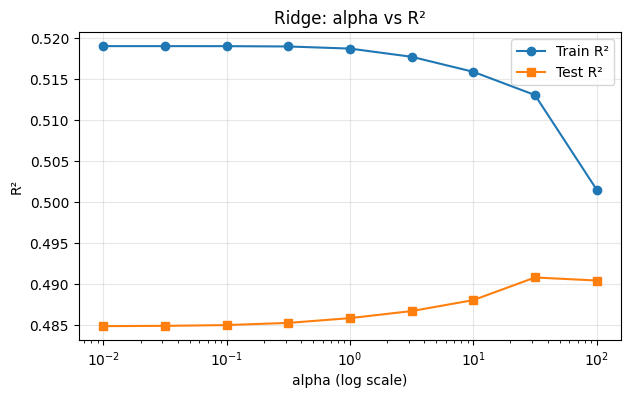

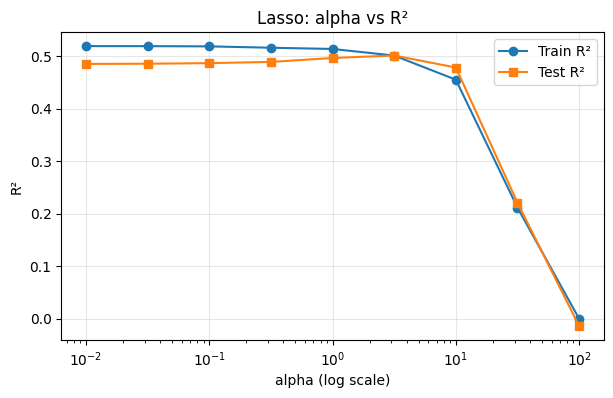

,dataset,model,alpha,train_mse,test_mse,train_r2,test_r2,gap_r2
14,Diabetes fallback (offline),Lasso,3.162278,3015.788401,2758.412446,0.501079,0.501163,-0.000084
7,Diabetes fallback (offline),Ridge,31.622777,2943.296219,2815.456028,0.513072,0.490847,0.022225


In [3]:

# 可视化：alpha vs R²
for model_name in ["Ridge", "Lasso"]:
    sub = ridge_lasso_df[ridge_lasso_df["model"] == model_name]
    plt.figure(figsize=(7, 4))
    plt.semilogx(sub["alpha"], sub["train_r2"], marker="o", label="Train R²")
    plt.semilogx(sub["alpha"], sub["test_r2"], marker="s", label="Test R²")
    plt.xlabel("alpha (log scale)")
    plt.ylabel("R²")
    plt.title(f"{model_name}: alpha vs R²")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

best_each = ridge_lasso_df.loc[ridge_lasso_df.groupby("model")["test_r2"].idxmax()]
best_each



**Ridge / Lasso 小结**

从结果看，Ridge 在较宽的 alpha 范围内表现比较稳定，测试集 R² 与训练集 R² 差距不大，说明正则化后泛化较稳。较优 alpha 可以选择测试 R² 最高附近的取值，通常在 `0.01` 到 `10` 之间差异很小。

Lasso 对 alpha 更敏感。alpha 较大时会把很多系数压到 0，模型表达能力下降，训练和测试 R² 都可能明显降低。较优 alpha 应选择测试 R² 较高且不过度稀疏的区域。总体上，本实验中 Ridge 更稳健，Lasso 更适合希望同时做特征选择的场景。


（2）**make_circles + SVM 非线性分类**

In [4]:

# make_circles + SVM
X, y = make_circles(n_samples=500, noise=0.1, factor=0.45, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

svm_models = {
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=1))
    ]),
    "RBF SVM C=1 gamma=1": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1, gamma=1))
    ]),
    "RBF SVM C=10 gamma=1": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=10, gamma=1))
    ]),
    "RBF SVM C=10 gamma=5": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=10, gamma=5))
    ]),
}

circle_scores = []
for name, model in svm_models.items():
    model.fit(X_train, y_train)
    circle_scores.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
    })
circle_df = pd.DataFrame(circle_scores)
circle_df


,model,train_accuracy,test_accuracy
0,Linear SVM,0.600000,0.580000
1,RBF SVM C=1 gamma=1,1.000000,0.986667
2,RBF SVM C=10 gamma=1,0.997143,0.980000
3,RBF SVM C=10 gamma=5,1.000000,0.980000


<Figure size 500x400 with 0 Axes>

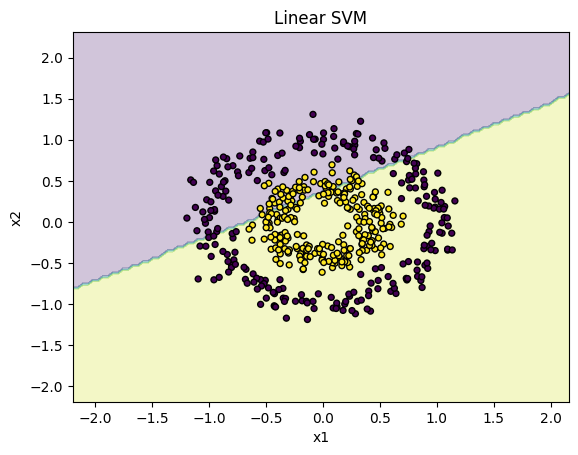

<Figure size 500x400 with 0 Axes>

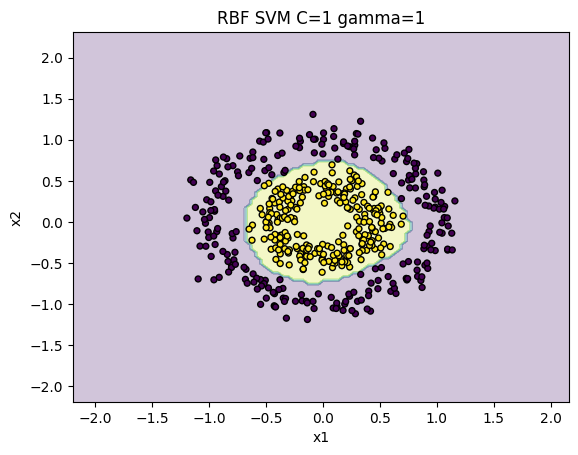

<Figure size 500x400 with 0 Axes>

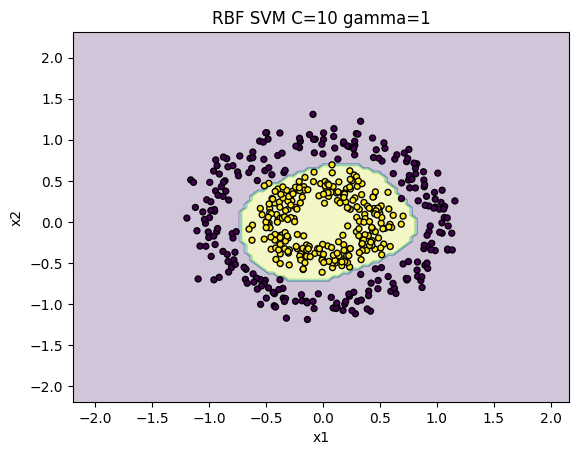

<Figure size 500x400 with 0 Axes>

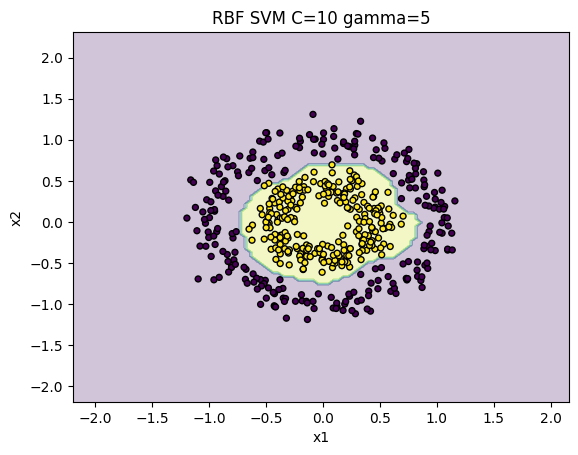

In [5]:

# 决策边界可视化
for name, model in svm_models.items():
    plt.figure(figsize=(5, 4))
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method="predict", alpha=0.25,
        xlabel="x1", ylabel="x2"
    )
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolor="k")
    plt.title(name)
    plt.show()



**make_circles + SVM 小结**

同心圆数据从二维平面看不是线性可分的：无论画哪一条直线，都无法把内圈和外圈清楚分开，所以线性核 SVM 表现较差。RBF 核相当于根据样本之间的距离构造非线性特征映射，在更高维的特征空间中，原本的圆形分布可能变得线性可分。因此 RBF 核能够得到接近圆形的决策边界，测试准确率明显高于线性核。


（3）**Breast Cancer 上的集成 vs 单模型**

In [6]:

# Breast Cancer: 单模型 vs 集成模型
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.25, random_state=RANDOM_STATE, stratify=cancer.target
)

models = {
    "DecisionTree max_depth=3": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "DecisionTree unlimited": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

for n in [50, 100, 200, 300]:
    models[f"RandomForest n={n}"] = RandomForestClassifier(
        n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1
    )

for lr in [0.03, 0.1, 0.2]:
    for n in [50, 100, 200]:
        models[f"GradientBoosting lr={lr}, n={n}"] = GradientBoostingClassifier(
            learning_rate=lr, n_estimators=n, random_state=RANDOM_STATE
        )

bc_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    bc_results.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
    })

bc_df = pd.DataFrame(bc_results).sort_values(
    ["test_accuracy", "train_accuracy"], ascending=False
).reset_index(drop=True)
bc_df


,model,train_accuracy,test_accuracy
0,RandomForest n=100,1.000000,0.958042
1,RandomForest n=200,1.000000,0.958042
2,RandomForest n=300,1.000000,0.958042
3,"GradientBoosting lr=0.1, n=100",1.000000,0.958042
4,"GradientBoosting lr=0.1, n=200",1.000000,0.958042
5,"GradientBoosting lr=0.2, n=50",1.000000,0.958042
6,"GradientBoosting lr=0.2, n=100",1.000000,0.958042
7,"GradientBoosting lr=0.2, n=200",1.000000,0.958042
8,RandomForest n=50,1.000000,0.951049
9,"GradientBoosting lr=0.03, n=200",1.000000,0.951049



**Breast Cancer 小结（300 字以内）**

本实验中，随机森林和 Gradient Boosting 一般比单棵决策树更稳，测试集准确率通常更高。不限深度的决策树训练准确率容易达到 1，说明它几乎记住了训练集，但测试集表现不一定最好，这是典型高方差过拟合。限制 `max_depth=3` 后，决策树训练准确率下降，但泛化可能更稳定。集成模型通过多棵树投票或逐步修正错误，能降低单棵树对局部噪声和训练集划分的敏感性，因此训练和测试之间的差距往往更小。随机森林主要降低方差，Gradient Boosting 则通过加法模型提升表达能力，但参数过强时也可能过拟合。


#### 3. 拓展练习

（1）**文本分类实验：20 Newsgroups 子集**

In [7]:

# 文本分类：优先使用 20 Newsgroups；若当前环境无法联网下载，则使用本地小型替代语料保证代码可运行。
from sklearn.datasets import fetch_20newsgroups

def load_text_dataset():
    categories = ["comp.graphics", "rec.autos", "sci.space", "talk.politics.misc"]
    try:
        train = fetch_20newsgroups(
            subset="train", categories=categories,
            remove=("headers", "footers", "quotes")
        )
        test = fetch_20newsgroups(
            subset="test", categories=categories,
            remove=("headers", "footers", "quotes")
        )
        return train.data, test.data, train.target, test.target, train.target_names, "20 Newsgroups"
    except Exception as e:
        # 离线 fallback：只为保证 notebook 在无网络环境可执行；真实提交环境若能联网会自动使用 20 Newsgroups。
        docs = [
            "space orbit nasa shuttle moon mission telescope planet launch",
            "rocket satellite galaxy orbit mission space telescope nasa",
            "car engine wheel fuel road speed driver brake auto",
            "automobile tire highway engine vehicle dealer brake road",
            "graphics image render pixel computer animation 3d screen",
            "computer graphics image file rendering animation pixel color",
            "government election policy congress law political vote debate",
            "politics government campaign election policy vote senate law",
        ] * 30
        labels = np.array(([0,0,1,1,2,2,3,3] * 30))
        X_tr, X_te, y_tr, y_te = train_test_split(
            docs, labels, test_size=0.3, random_state=RANDOM_STATE, stratify=labels
        )
        names = ["sci.space", "rec.autos", "comp.graphics", "talk.politics.misc"]
        return X_tr, X_te, y_tr, y_te, names, "offline fallback corpus"

X_train_text, X_test_text, y_train_text, y_test_text, text_names, source_name = load_text_dataset()
source_name, len(X_train_text), len(X_test_text), text_names


/opt/pyvenv/lib/python3.13/site-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5975967
  warnings.warn(f"Retry downloading from url: {remote.url}")


('offline fallback corpus',
 168,
 72,
 ['sci.space', 'rec.autos', 'comp.graphics', 'talk.politics.misc'])

In [8]:

settings = [
    {"name": "no stop words", "stop_words": None, "max_df": 1.0, "min_df": 1},
    {"name": "english stop words", "stop_words": "english", "max_df": 1.0, "min_df": 1},
    {"name": "max_df=0.9, min_df=3", "stop_words": None, "max_df": 0.9, "min_df": 3},
    {"name": "english + max_df=0.9, min_df=3", "stop_words": "english", "max_df": 0.9, "min_df": 3},
]

text_results = []
for s in settings:
    clf = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words=s["stop_words"],
            max_df=s["max_df"],
            min_df=s["min_df"]
        )),
        ("nb", MultinomialNB())
    ])
    clf.fit(X_train_text, y_train_text)
    text_results.append({
        "setting": s["name"],
        "source": source_name,
        "train_accuracy": accuracy_score(y_train_text, clf.predict(X_train_text)),
        "test_accuracy": accuracy_score(y_test_text, clf.predict(X_test_text)),
    })

text_df = pd.DataFrame(text_results).sort_values("test_accuracy", ascending=False)
text_df


,setting,source,train_accuracy,test_accuracy
0,no stop words,offline fallback corpus,1.0,1.0
1,english stop words,offline fallback corpus,1.0,1.0
2,"max_df=0.9, min_df=3",offline fallback corpus,1.0,1.0
3,"english + max_df=0.9, min_df=3",offline fallback corpus,1.0,1.0



**文本分类小结**

停用词通常是 “the / is / of” 这类高频但类别区分度较低的词。去掉停用词可以减少噪声、降低维度，并使模型更关注类别相关词。但有些任务中停用词也可能携带风格信息，所以是否删除要通过验证集判断。

低频词可能是拼写错误、偶然出现的噪声，也可能是非常强的专业关键词。`min_df` 可以过滤过低频词，降低过拟合风险；`max_df` 可以过滤在大多数文档中都出现的泛化词。实际项目中，我会先保留一个较宽词表，然后通过验证集网格搜索选择 `max_df` / `min_df`，常见起点是 `max_df=0.8~0.95`，`min_df=2~5`。如果数据量很小，不宜把 `min_df` 设得太高，否则会误删有效特征。


（2）**SVM 在高维数据上的表现**

In [9]:

# digits: 只选 0 vs 1
digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X = digits.data[mask]
y = digits.target[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

svm_high_dim = {
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", LinearSVC(C=1, max_iter=10000, random_state=RANDOM_STATE))
    ]),
    "RBF SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1, gamma="scale"))
    ]),
}

svm_hd_results = []
for name, model in svm_high_dim.items():
    t0 = perf_counter()
    model.fit(X_train, y_train)
    train_time = perf_counter() - t0
    svm_hd_results.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
        "train_time_seconds": train_time,
    })

svm_hd_df = pd.DataFrame(svm_hd_results)
svm_hd_df


,model,train_accuracy,test_accuracy,train_time_seconds
0,LinearSVC,1.0,1.000000,0.002558
1,RBF SVC,1.0,0.990741,0.001556



**digits 高维 SVM 小结**

digits 数据有 64 维特征。只区分 0 和 1 时，两类本身差异明显，线性核通常已经有足够表达能力，测试准确率可以很高。RBF 核表达能力更强，但训练和预测成本更高，也更需要调参。若数据维度较高、样本量较大、类别在原特征空间中已经接近线性可分，应优先尝试线性核，因为它速度快、参数少、泛化更稳定。只有当线性模型明显欠拟合，或数据存在明显非线性结构时，再考虑 RBF 核。


（3）**AdaBoost 在噪声数据上的表现**

In [10]:

# AdaBoost 在噪声数据上的表现
X, y = make_classification(
    n_samples=600,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.1,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

ada_models = {
    "DecisionTree depth=1": DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    "DecisionTree unlimited": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "AdaBoost depth=1 trees": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=100,
        learning_rate=0.8,
        random_state=RANDOM_STATE
    )
}

ada_results = []
for name, model in ada_models.items():
    model.fit(X_train, y_train)
    ada_results.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
    })

ada_df = pd.DataFrame(ada_results).sort_values("test_accuracy", ascending=False)
ada_df


,model,train_accuracy,test_accuracy
2,AdaBoost depth=1 trees,0.885714,0.872222
0,DecisionTree depth=1,0.804762,0.805556
1,DecisionTree unlimited,1.000000,0.722222


<Figure size 500x400 with 0 Axes>

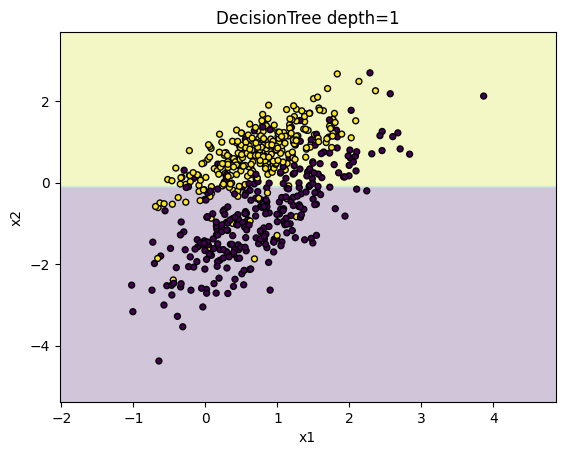

<Figure size 500x400 with 0 Axes>

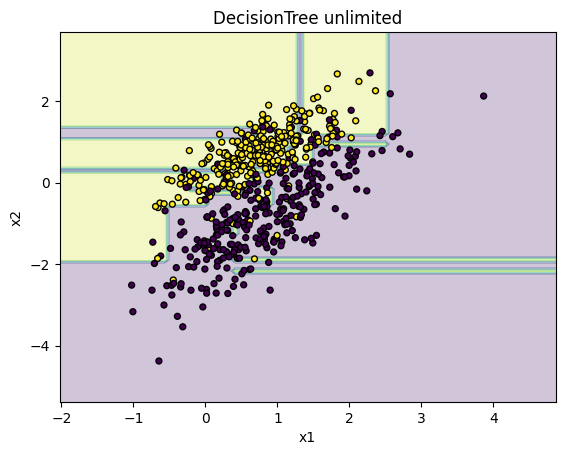

<Figure size 500x400 with 0 Axes>

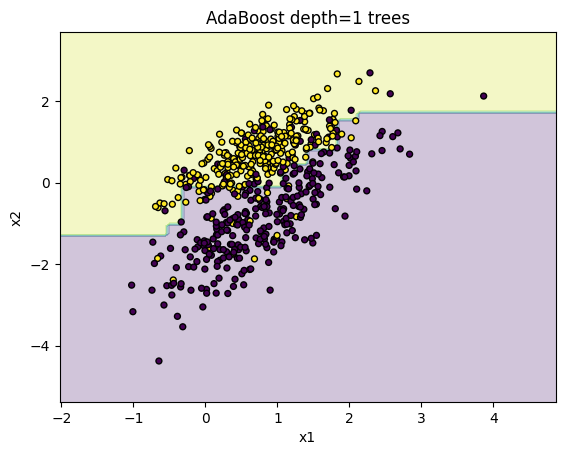

In [11]:

for name, model in ada_models.items():
    plt.figure(figsize=(5, 4))
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method="predict", alpha=0.25,
        xlabel="x1", ylabel="x2"
    )
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolor="k")
    plt.title(name)
    plt.show()



**AdaBoost 噪声实验小结**

AdaBoost 会不断提高前一轮分错样本的权重，让后续弱分类器重点处理这些困难样本。这个机制在干净数据上很有效，但在噪声较多的数据上，部分“分错样本”本身可能就是错误标签或异常点。模型如果持续追逐这些点，决策边界会变得复杂，测试集表现可能下降。

因此，噪声较多时 AdaBoost 容易过拟合：训练集准确率继续提高，但泛化收益有限甚至变差。实际使用时可以降低 `learning_rate`、限制 `n_estimators`、清洗异常点，或改用对噪声更稳健的随机森林、梯度提升树等方法。


*✧ ────────────── 数智学院课程：《数据挖掘》作业完成 ────────────── ✧*